In [ ]:
#ddbnetcdf_path = os.path.join(base_scratch_dir, 'MESH-CanTrans/MESH_0p0_0p0_drainage_database.nc')
#ddbnetcdf_path = os.path.join(base_scratch_dir, 'MESH-CanTrans/MESH_0p05_0p01_drainage_database.nc')
#ddbnetcdf_path = os.path.join(base_scratch_dir, 'MESH-CanTrans/MESH_0p01_0p001_drainage_database.nc')
#lake_shapefile_path = os.path.join(base_scratch_dir, 'gis-datastorage/HydroLAKES_polys_v10_shp/HydroLAKES_polys_ncrb.shp')
#transbodr_path = os.path.join(base_scratch_dir, 'gis-datastorage/WBD_09_HU2_Shape/Shape/WBDHU2.shp')
#subbasin_dissolved_path = os.path.join(base_scratch_dir, 'gis-datastorage/NCRB_SubbasinsDissolved.shp')
#
##rivers_75_path = '/scratch/fuaday/J_Core_modeling/Nelson_project/Input_data_NCRB/Input_data_NCRB/NCRB_shapefiles/NCRB_River_75.shp'
#rivers_75_path = '/scratch/fuaday/ncrb-agg-model/gis-datastorage/ncrb_rivers_cec_2023latlon.shp'

In [2]:
## Function to plot GRU / Land cover fraction by subbasin
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FixedLocator, FuncFormatter
import netCDF4 as nc
from typing import List, Optional, Tuple


def plot_landuse_gru_distribution(
    output_basin_path: str,
    boundary_path: str,
    border_path: str,
    ddbnetcdf_path: str,
    titles: Optional[List[str]] = None,
    exclude_gru: Optional[List[int]] = None,
    figsize: Tuple[int, int] = (20, 9),
    cmap_name: str = "gnuplot2_r",
    output_png: Optional[str] = "landuse_gru_distribution.png",
    dpi: int = 300,
) -> None:

    # === Load geospatial layers ===
    print("Loading geospatial layers...")
    sub_agg_gdf = gpd.read_file(output_basin_path).to_crs(epsg=4326)
    sub_agg_gdf["COMID"] = sub_agg_gdf["COMID"].astype(int)

    if "unitarea" not in sub_agg_gdf.columns:
        raise KeyError("Column 'unitarea' missing in subbasin shapefile!")

    sub_agg_gdf["area_km2"] = sub_agg_gdf["unitarea"]

    boundary_gdf = gpd.read_file(boundary_path).to_crs(epsg=4326)
    border_gdf = gpd.read_file(border_path).to_crs(epsg=4326)

    # === Read NetCDF ===
    print(f"Reading NetCDF: {os.path.basename(ddbnetcdf_path)}")
    with nc.Dataset(ddbnetcdf_path, "r") as ds:

        subbasin_ids = np.nan_to_num(ds["subbasin"][:], nan=0).astype(int)

        # GRU array
        gru_raw = np.nan_to_num(ds["GRU"][:], nan=0.0)
        n_gru_total = gru_raw.shape[1]

        print(f"Detected {n_gru_total} total GRUs in file.")

        # Default: no excluded GRUs
        if exclude_gru is None:
            exclude_gru = []

        print(f"Excluding GRUs: {exclude_gru}")

        # Indices to keep
        keep_indices = [i for i in range(n_gru_total) if i not in exclude_gru]

        gru_data = gru_raw[:, keep_indices]
        n_gru = len(keep_indices)

        print(f"Using {n_gru} GRUs after exclusion: {keep_indices}")

    # === Titles: must match GRUs kept ===
    if titles is None:
        titles = [f"Class {i}" for i in keep_indices]
    elif len(titles) != n_gru:
        raise ValueError(f"titles must contain exactly {n_gru} elements.")

    # Column names reflect true GRU IDs
    landuse_classes = [f"GRU_{i}" for i in keep_indices]

    # === Prepare dataframe ===
    gru_df = pd.DataFrame(gru_data, columns=landuse_classes)
    gru_df.insert(0, "subbasin", subbasin_ids)

    merged_gdf = sub_agg_gdf.merge(
        gru_df, left_on="COMID", right_on="subbasin", how="left"
    )
    merged_gdf[landuse_classes] = merged_gdf[landuse_classes].fillna(0)

    # === Area-weighted percentages ===
    total_area = merged_gdf["area_km2"].sum()
    mean_percentages = [
        round((merged_gdf[col] * merged_gdf["area_km2"]).sum() / total_area * 100, 2)
        for col in landuse_classes
    ]

    # === Prepare figure ===
    rows, cols = 3, 5  # keep grid 3×5
    fig, axes = plt.subplots(
        rows, cols,
        figsize=figsize,
        sharex=True,
        sharey=True,
        constrained_layout=True
    )
    axes = axes.flatten()

    base_cmap = plt.get_cmap(cmap_name).copy()
    base_cmap.set_under("white")
    norm = mcolors.Normalize(vmin=0, vmax=1)

    # Tick formatting
    deg_formatter = FuncFormatter(lambda x, pos: f"{int(x)}°")
    desired_lons = np.arange(-180, 181, 20)
    desired_lats = np.arange(-90, 91, 20)

    # === Plot GRU maps ===
    for idx, (ax, col, title, mean_perc) in enumerate(
        zip(axes, landuse_classes, titles, mean_percentages)
    ):

        merged_gdf.plot(
            column=col,
            ax=ax,
            cmap=base_cmap,
            norm=norm,
            edgecolor="none",
            linewidth=0,
        )
        boundary_gdf.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=0.6)
        border_gdf.plot(ax=ax, edgecolor="red", facecolor="none", linewidth=0.9)

        ax.set_title(title, fontsize=12, pad=8)

        r, c = divmod(idx, cols)

        # Longitude (x-axis)
        if r == rows - 1:
            ax.xaxis.set_major_locator(FixedLocator(desired_lons))
            ax.xaxis.set_major_formatter(deg_formatter)
            ax.tick_params(labelbottom=True)
        else:
            ax.tick_params(labelbottom=False)

        # Latitude (y-axis)
        if c == 0:
            ax.yaxis.set_major_locator(FixedLocator(desired_lats))
            ax.yaxis.set_major_formatter(deg_formatter)
            ax.tick_params(labelleft=True)
        else:
            ax.tick_params(labelleft=False)

        # Large axis labels
        if r == 1 and c == 0:
            ax.set_ylabel("Latitude", fontsize=15, labelpad=20)
        if r == rows - 1 and c == 2:
            ax.set_xlabel("Longitude", fontsize=15, labelpad=12)

        # Percent text (no bounding box)
        ax.text(
            0.04,
            0.94,
            f"{mean_perc:.2f}%",
            transform=ax.transAxes,
            fontsize=12,
            color="black",
            va="top",
            ha="left",
        )

    # === Colorbar OUTSIDE ===
    sm = plt.cm.ScalarMappable(cmap=base_cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes,
        location="right",
        fraction=0.03,
        pad=0.02
    )

    cbar.ax.tick_params(labelsize=13)
    cbar.set_label("GRU Fraction", rotation=270, labelpad=30, fontsize=16)

    # === Title ===
    fig.suptitle(
        "Land Cover Distribution by GRU (Area-Weighted Basin Percentage)",
        fontsize=17
    )

    if output_png:
        plt.savefig(output_png, dpi=dpi, bbox_inches="tight")
        print(f"Saved → {output_png}")

    plt.show()

Loading geospatial layers...
Reading NetCDF: MESH_drainage_database.nc
Detected 17 total GRUs in file.
Excluding GRUs: [0, 16]
Using 15 GRUs after exclusion: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Saved → NALCMS_org_landuse_GRU_distribution_clean.png


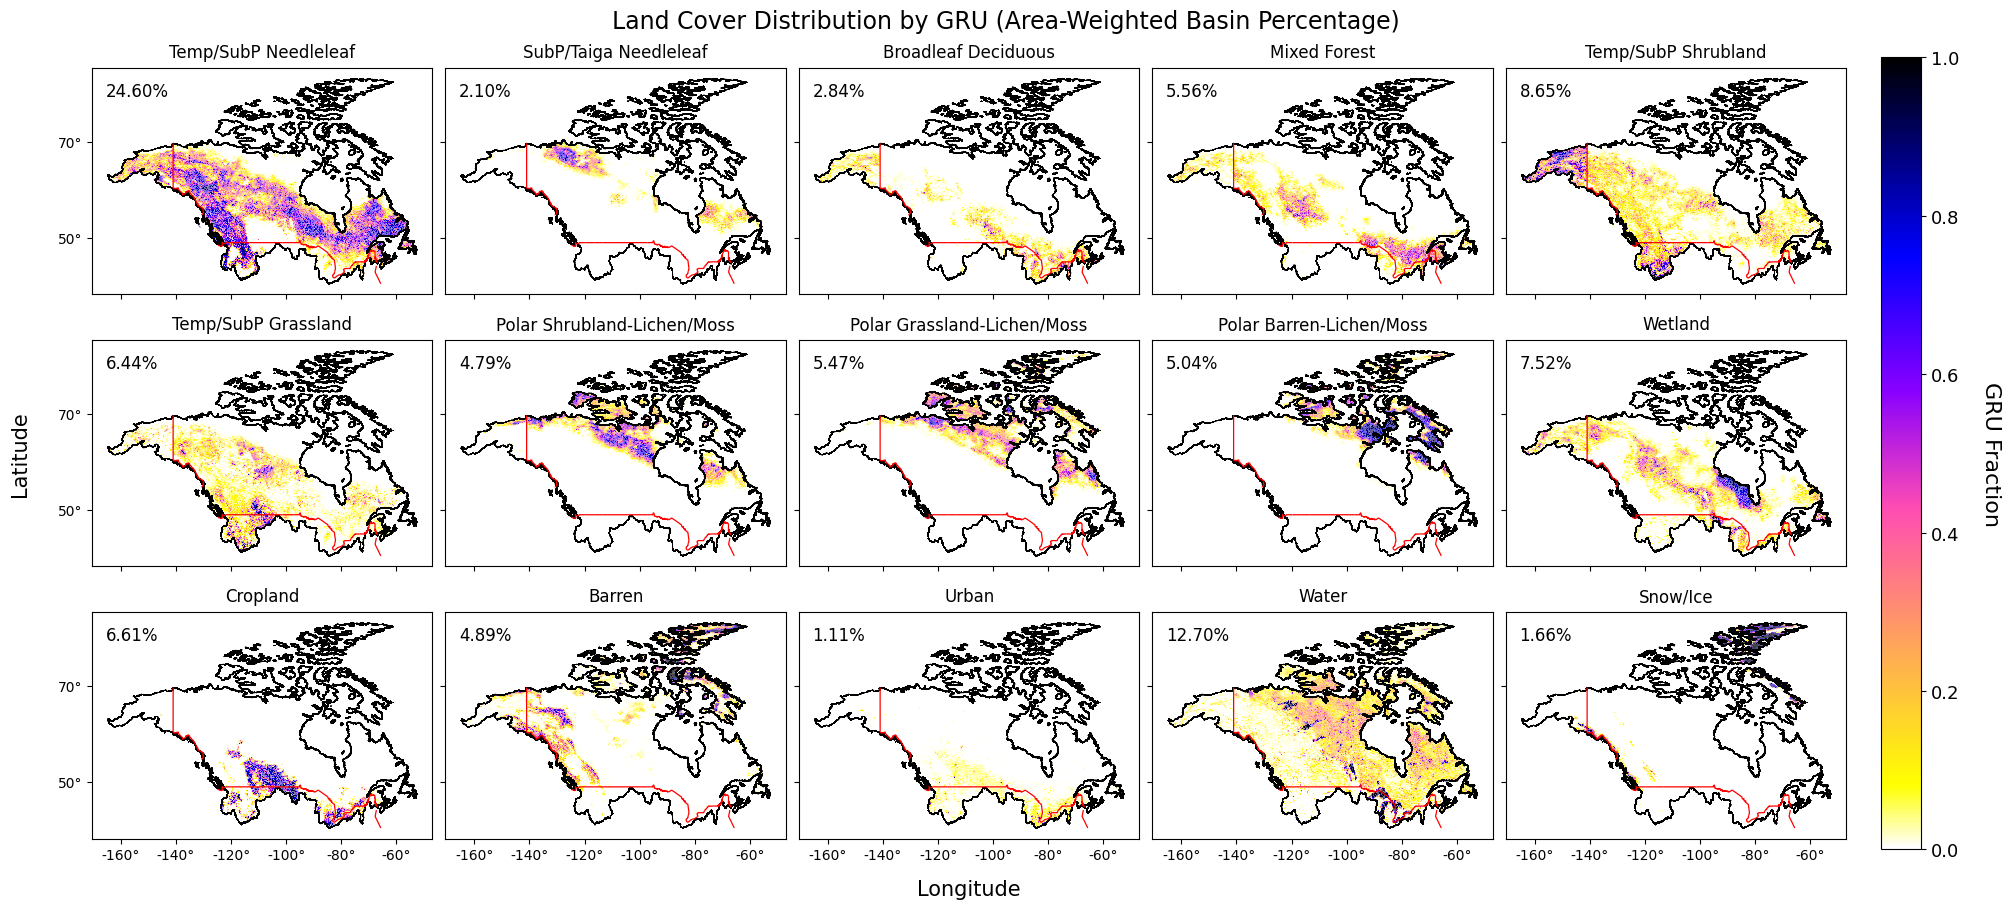

In [3]:
# === Example usage ===
if __name__ == "__main__":
    base_dir = "/home/zelalem/github-repos"
    # GRUs to exclude (0-based index)
    # Example: exclude the last GRU (14)
    exclude_list = [0, 16]
    example_titles = [
        "Temp/SubP Needleleaf", "SubP/Taiga Needleleaf",
        "Broadleaf Deciduous", "Mixed Forest",
        "Temp/SubP Shrubland", "Temp/SubP Grassland",
        "Polar Shrubland-Lichen/Moss", "Polar Grassland-Lichen/Moss",
        "Polar Barren-Lichen/Moss", "Wetland", "Cropland",
        "Barren", "Urban", "Water", "Snow/Ice"
    ]
# run the plotting function
    plot_landuse_gru_distribution(
        output_basin_path=os.path.join(
            base_dir,
            "community-workflows/1-geofabric/MERIT/CanTrans-merit-geofabric/agg_MERIT_CanTrans_subbasins.shp"
        ),
        boundary_path=os.path.join(
            base_dir,
            "community-workflows/1-geofabric/study-domain/CanTrans_MERIT_StudyDomain.shp"
        ),
        border_path=os.path.join(
            base_dir,
            "community-workflows/1-geofabric/study-domain/US-Canada_Boundary_v1_3.shp"
        ),
        ddbnetcdf_path=os.path.join(
            base_dir,
            "merit_mesh_outputs_landsat/MESH_drainage_database.nc"
        ),
        titles=example_titles,  # or provide a list of titles matching n_gru-1
        exclude_gru=exclude_list,
        output_png="NALCMS_org_landuse_GRU_distribution_clean.png",
        dpi=300
    )

Loading geospatial layers...
Reading NetCDF: MESH_drainage_database_Polish_0p05_0p02_0p01.nc
Detected 16 total GRUs in file.
Excluding GRUs: [15]
Using 15 GRUs after exclusion: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Saved → NALCMS_Polish_landuse_GRU_distribution_clean.png


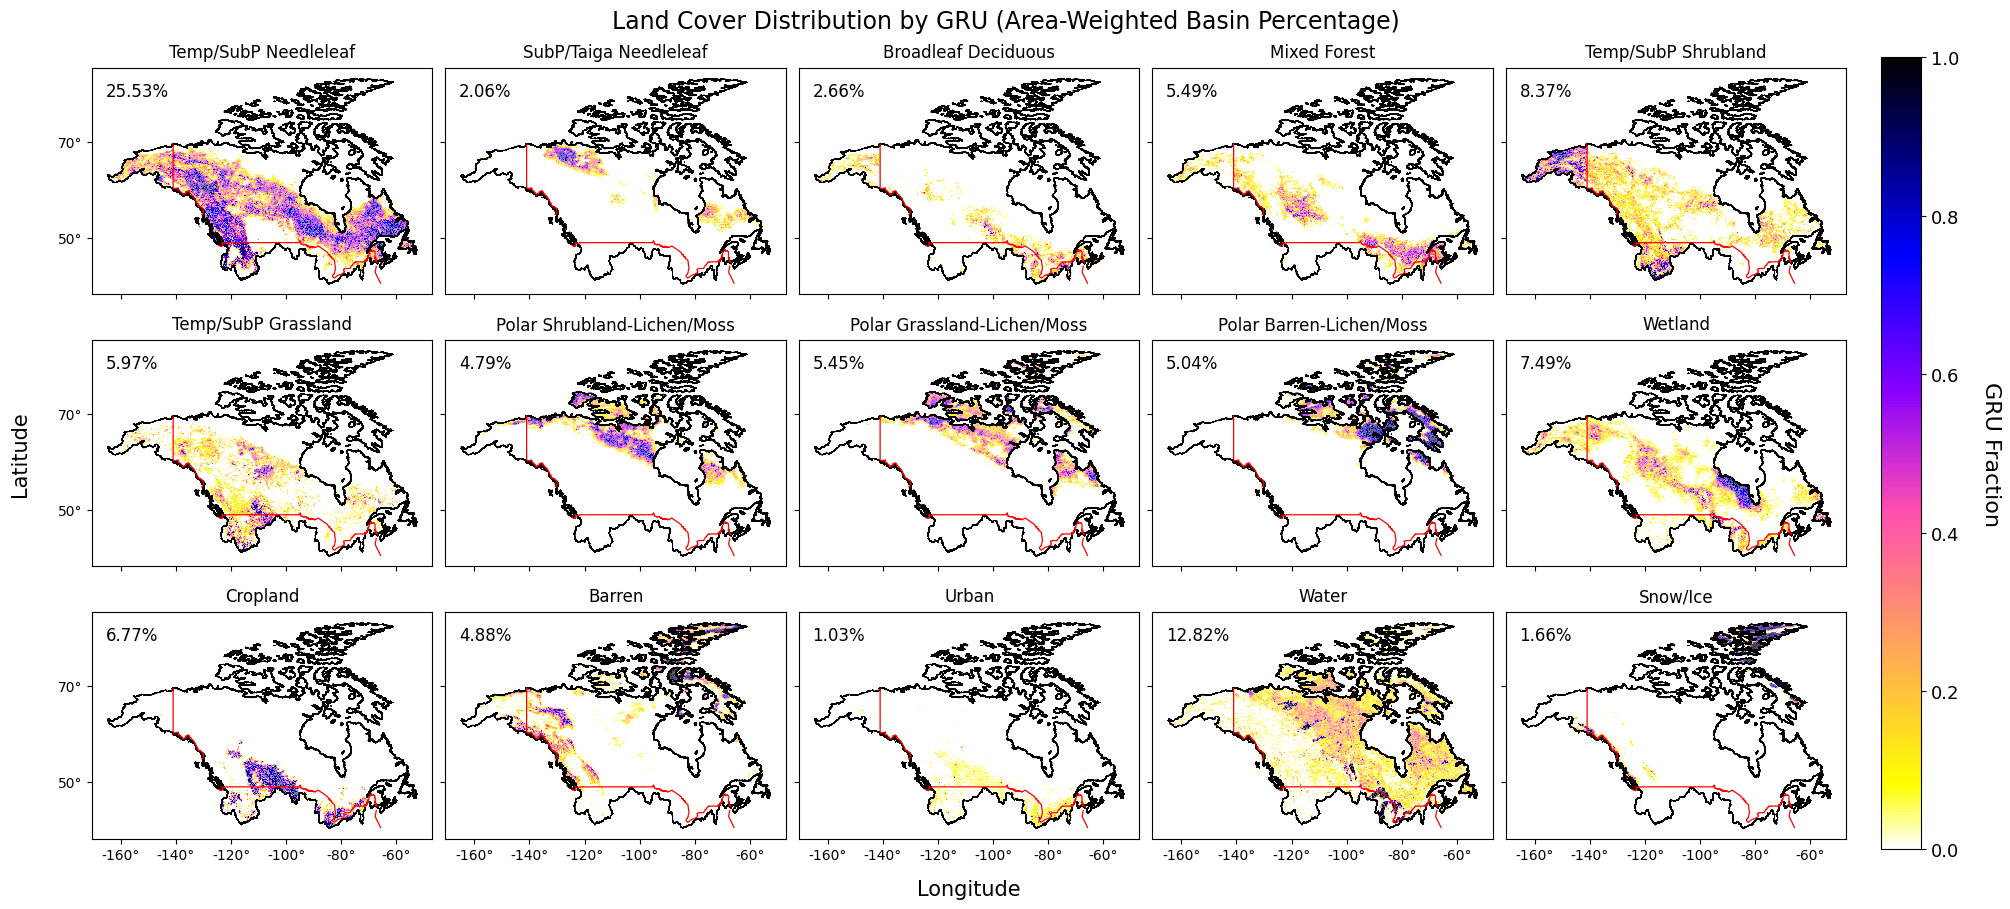

In [5]:
# === Example usage ===
if __name__ == "__main__":
    base_dir = "/home/zelalem/github-repos"
    # GRUs to exclude (0-based index)
    # Example: exclude the last GRU (14)
    exclude_list = [15]
    example_titles = [
        "Temp/SubP Needleleaf", "SubP/Taiga Needleleaf",
        "Broadleaf Deciduous", "Mixed Forest",
        "Temp/SubP Shrubland", "Temp/SubP Grassland",
        "Polar Shrubland-Lichen/Moss", "Polar Grassland-Lichen/Moss",
        "Polar Barren-Lichen/Moss", "Wetland", "Cropland",
        "Barren", "Urban", "Water", "Snow/Ice"
    ]
# run the plotting function
    plot_landuse_gru_distribution(
        output_basin_path=os.path.join(
            base_dir,
            "community-workflows/1-geofabric/MERIT/CanTrans-merit-geofabric/agg_MERIT_CanTrans_subbasins.shp"
        ),
        boundary_path=os.path.join(
            base_dir,
            "community-workflows/1-geofabric/study-domain/CanTrans_MERIT_StudyDomain.shp"
        ),
        border_path=os.path.join(
            base_dir,
            "community-workflows/1-geofabric/study-domain/US-Canada_Boundary_v1_3.shp"
        ),
        ddbnetcdf_path=os.path.join(
            base_dir,
            "merit_mesh_outputs_landsat/MESH_drainage_database_Polish_0p05_0p02_0p01.nc"
        ),
        titles=example_titles,  # or provide a list of titles matching n_gru-1
        exclude_gru=exclude_list,
        output_png="NALCMS_Polish_landuse_GRU_distribution_clean.png",
        dpi=300
    )

Loading geospatial layers...
Reading NetCDF: MESH_drainage_database_rev.nc
Detected 17 total GRUs in file.
Excluding GRUs: [0, 16]
Using 15 GRUs after exclusion: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Saved → ESA_org_landuse_GRU_distribution_clean.png


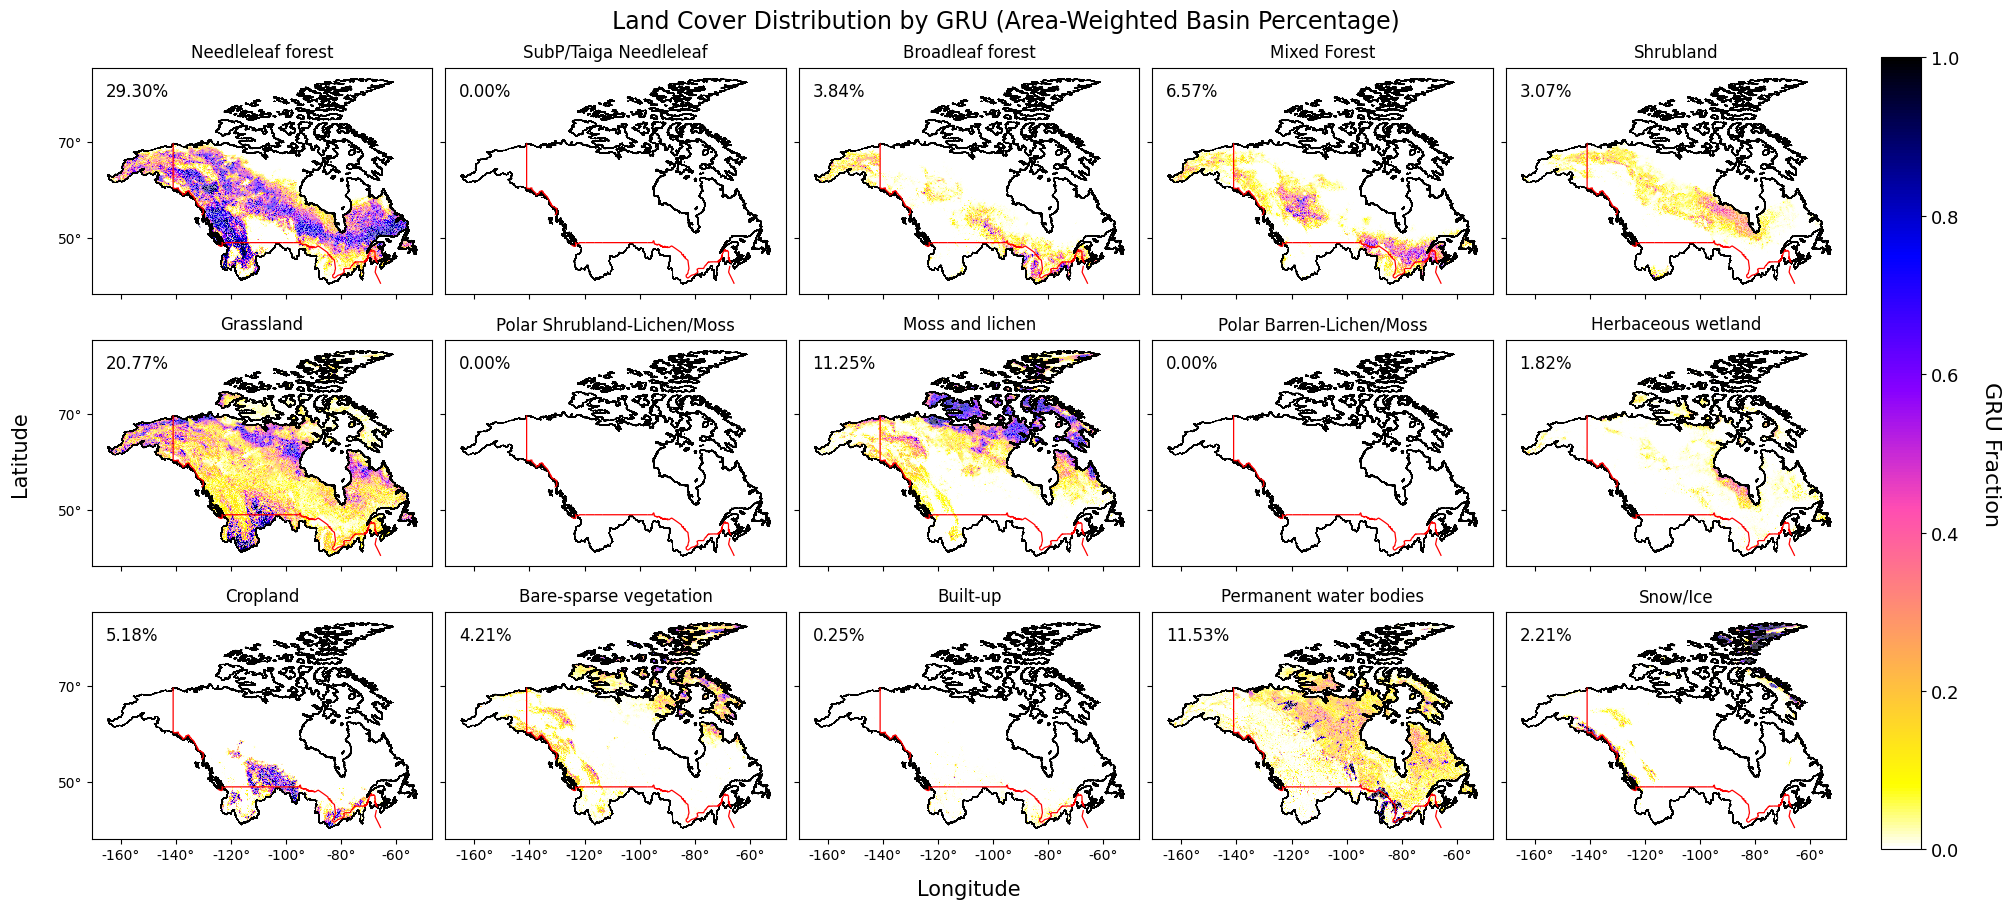

In [6]:
# === Example usage ===
if __name__ == "__main__":
    base_dir = "/home/zelalem/github-repos"
    # GRUs to exclude (0-based index)
    # Example: exclude the last GRU (14)
    exclude_list = [0, 16]
    example_titles = [
        "Needleleaf forest", "SubP/Taiga Needleleaf",
        "Broadleaf forest", "Mixed Forest",
        "Shrubland", "Grassland",
        "Polar Shrubland-Lichen/Moss", "Moss and lichen",
        "Polar Barren-Lichen/Moss", "Herbaceous wetland", 
        "Cropland", "Bare-sparse vegetation", 
        "Built-up", "Permanent water bodies", "Snow/Ice"
    ]
# run the plotting function
    plot_landuse_gru_distribution(
        output_basin_path=os.path.join(
            base_dir,
            "community-workflows/1-geofabric/MERIT/CanTrans-merit-geofabric/agg_MERIT_CanTrans_subbasins.shp"
        ),
        boundary_path=os.path.join(
            base_dir,
            "community-workflows/1-geofabric/study-domain/CanTrans_MERIT_StudyDomain.shp"
        ),
        border_path=os.path.join(
            base_dir,
            "community-workflows/1-geofabric/study-domain/US-Canada_Boundary_v1_3.shp"
        ),
        ddbnetcdf_path=os.path.join(
            base_dir,
            "merit_mesh_outputs_esa/MESH_drainage_database_rev.nc"
        ),
        titles=example_titles,  # or provide a list of titles matching n_gru-1
        exclude_gru=exclude_list,
        output_png="ESA_org_landuse_GRU_distribution_clean.png",
        dpi=300
    )

In [ ]:
# === Example usage ===
if __name__ == "__main__":
    base_dir = "/home/zelalem/github-repos"
    # GRUs to exclude (0-based index)
    # Example: exclude the last GRU (14)
    exclude_list = [15]
    example_titles = [
        "Needleleaf forest", "SubP/Taiga Needleleaf",
        "Broadleaf forest", "Mixed Forest",
        "Shrubland", "Grassland",
        "Polar Shrubland-Lichen/Moss", "Moss and lichen",
        "Polar Barren-Lichen/Moss", "Herbaceous wetland", 
        "Cropland", "Bare-sparse vegetation", 
        "Built-up", "Permanent water bodies", "Snow/Ice"
    ]
# run the plotting function
    plot_landuse_gru_distribution(
        output_basin_path=os.path.join(
            base_dir,
            "community-workflows/1-geofabric/MERIT/CanTrans-merit-geofabric/agg_MERIT_CanTrans_subbasins.shp"
        ),
        boundary_path=os.path.join(
            base_dir,
            "community-workflows/1-geofabric/study-domain/CanTrans_MERIT_StudyDomain.shp"
        ),
        border_path=os.path.join(
            base_dir,
            "community-workflows/1-geofabric/study-domain/US-Canada_Boundary_v1_3.shp"
        ),
        ddbnetcdf_path=os.path.join(
            base_dir,
            "merit_mesh_outputs_esa/MESH_drainage_database_Polish_0p05_0p02_0p01.nc"
        ),
        titles=example_titles,  # or provide a list of titles matching n_gru-1
        exclude_gru=exclude_list,
        output_png="ESA_Polish_landuse_GRU_distribution_clean.png",
        dpi=300
    )

Loading geospatial layers...
Reading NetCDF: MESH_drainage_database_Polish_0p05_0p02_0p01.nc
Detected 16 total GRUs in file.
Excluding GRUs: [15]
Using 15 GRUs after exclusion: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
